In [9]:
from google.colab import files
uploaded = files.upload()  # a button will appear, click and upload your CSV

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [11]:
df = pd.read_csv('PS_20174392719_1491204439457_log.csv', nrows=100000)
print(df.shape)
print(df['isFraud'].value_counts())
df.head()

(100000, 11)
isFraud
0    99884
1      116
Name: count, dtype: int64


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [12]:
# Drop irrelevant columns
df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'], inplace=True)

# Label encode transaction type
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

# Add balance delta feature
df['balance_delta_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_delta_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

# Separate features and label
X = df.drop(columns=['isFraud'])
y = df['isFraud']

# Normalize
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)
print("After SMOTE:", pd.Series(y_res).value_counts())

After SMOTE: isFraud
0    99884
1    99884
Name: count, dtype: int64


In [14]:
# GRU needs 3D input: (samples, timesteps, features)
X_res = X_res.reshape((X_res.shape[0], 1, X_res.shape[1]))

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (159814, 1, 9)
Test shape: (39954, 1, 9)


In [15]:
model = Sequential([
    GRU(64, return_sequences=True, input_shape=(1, X_train.shape[2])),
    Dropout(0.3),
    GRU(32),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3,
                           restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=256,
                    validation_split=0.1,
                    callbacks=[early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 1, 64)          │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,841 (93.13 KB)

 Trainable params: 23,841 (93.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7741 - loss: 0.4830 - val_accuracy: 0.8040 - val_loss: 0.4132
Epoch 2/20
562/562 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8320 - loss: 0.3753 - val_accuracy: 0.8630 - val_loss: 0.3273
Epoch 3/20
562/562 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8645 - loss: 0.3170 - val_accuracy: 0.8815 - val_loss: 0.2835
Epoch 4/20
562/562 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8859 - loss: 0.2786 - val_accuracy: 0.9060 - val_loss: 0.2345
Epoch 5/20
562/562 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9085 - loss: 0.2369 - val_accuracy: 0.9218 - val_loss: 0.2125
Epoch 6/20
562/562 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9222 - loss: 0.2100 - val_accuracy: 0.9299 - val_loss: 0.1856
Epoch 7/20
562/562 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9315 - loss: 0.1914 - val_accuracy: 0.9372 - val_loss: 0.1654
Epoch 8/20
562/562 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9370 - loss: 0.1792 - val_accuracy: 0.

In [16]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Fraud']))

1249/1249 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
              precision    recall  f1-score   support

  Legitimate       0.96      0.95      0.96     19977
       Fraud       0.95      0.96      0.96     19977

    accuracy                           0.96     39954
   macro avg       0.96      0.96      0.96     39954
weighted avg       0.96      0.96      0.96     39954



/tmp/ipykernel_1430/236033535.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Legitimate', 'Fraud'], y=df_orig_counts.values,


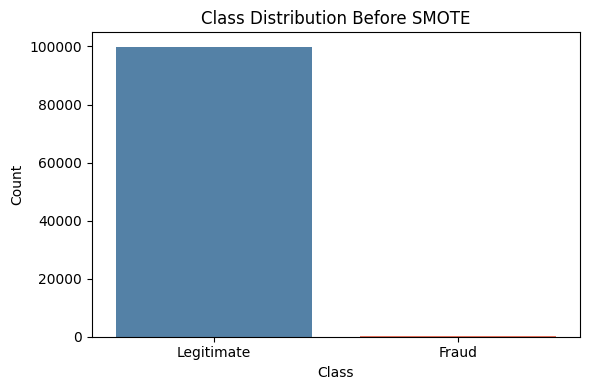

In [17]:
plt.figure(figsize=(6,4))
df_orig_counts = pd.Series(y).value_counts()
sns.barplot(x=['Legitimate', 'Fraud'], y=df_orig_counts.values,
            palette=['steelblue','tomato'])
plt.title('Class Distribution Before SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300)
plt.show()

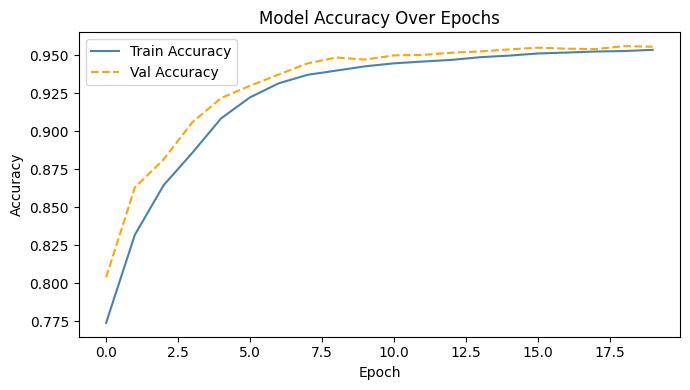

In [18]:
plt.figure(figsize=(7,4))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy',
         color='orange', linestyle='--')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_curve.png', dpi=300)
plt.show()

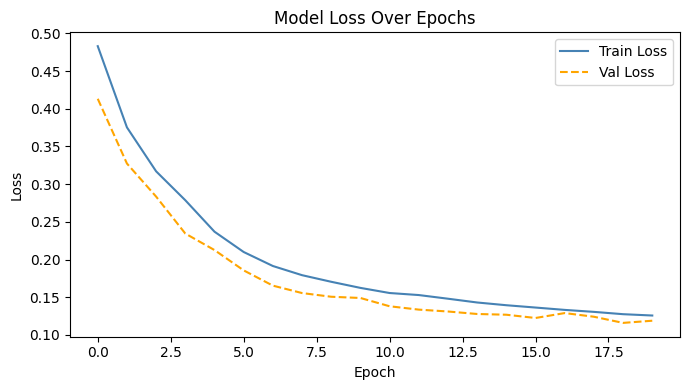

In [19]:
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='Train Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Val Loss',
         color='orange', linestyle='--')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=300)
plt.show()

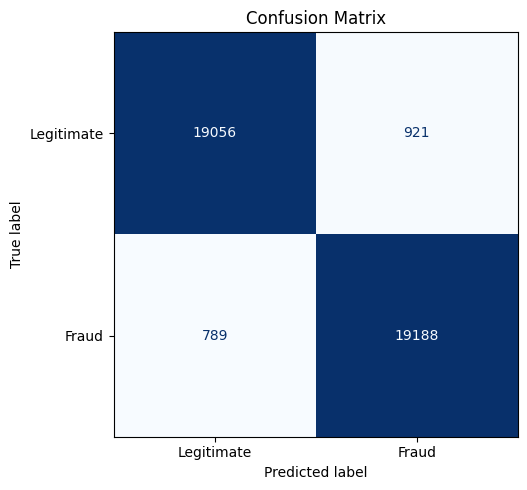

In [20]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legitimate', 'Fraud'])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

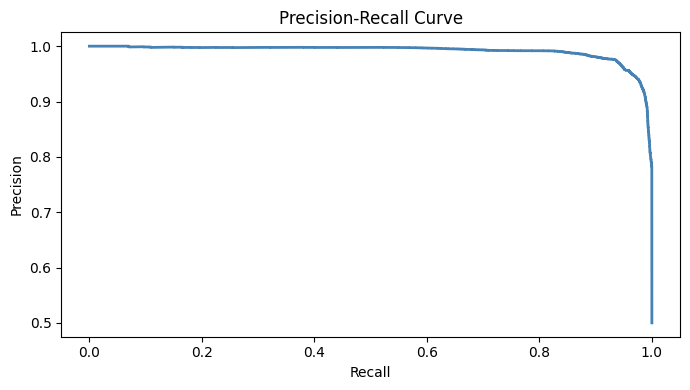

In [21]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
plt.figure(figsize=(7,4))
plt.plot(recall, precision, color='steelblue', lw=2)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=300)
plt.show()

In [22]:
# Download all graphs
from google.colab import files
files.download('class_distribution.png')
files.download('accuracy_curve.png')
files.download('loss_curve.png')
files.download('confusion_matrix.png')
files.download('precision_recall_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>